In [4]:
import matplotlib.pyplot as plt
import os
#from utilites import read_data_from_timestep
import numpy as np
import pandas as pd
import csv


folder_path = os.path.join("../data_for_plots", "moving_vs_resting_bubble", "line_data_rho1_v01_circular")

frames_cm = []
frames_mrt = []

U0 = 0.01
n = np.arange(127, 999, 128)
# n = np.arange(127, 256, 128)
i = np.arange(len(n))

u_diff = np.empty(len(n))
rho_diff = np.empty(len(n))

pf_cm_CMx = np.empty(len(n))  # x coordinate of the center of mass of the bubble
pf_mrt_CMx = np.empty(len(n))  # x coordinate of the center of mass of the bubble


for i_, n_ in zip(i, n):
    frame_cm = pd.read_csv(os.path.join(folder_path, "cm_moving.%d.csv" % n_), delimiter="\t")
    frame_mrt = pd.read_csv(os.path.join(folder_path, "mrt_moving.%d.csv" % n_), delimiter="\t")

    frames_cm.append(frame_cm)
    frames_mrt.append(frame_mrt)

    def find_CMx(pf, arc_x, n_, threshold=0.5):
        scale_factor = 1001/256 
        
        counter = 0
        weight = 0
        
        arc_x = np.roll(arc_x, U0*n*1001)
        
        for pf_, x_cm in zip(pf, arc_x):
            if pf_ > threshold:
                counter += x_cm*pf_
                weight += pf_

        ans = counter/weight
        return ans


    pf_cm_CMx[i_] = find_CMx(frame_cm['PhaseField'], frame_cm['arc_length'], n_)
    pf_mrt_CMx[i_] = find_CMx(frame_mrt['PhaseField'], frame_mrt['arc_length'], n_)


TypeError: slice indices must be integers or None or have an __index__ method

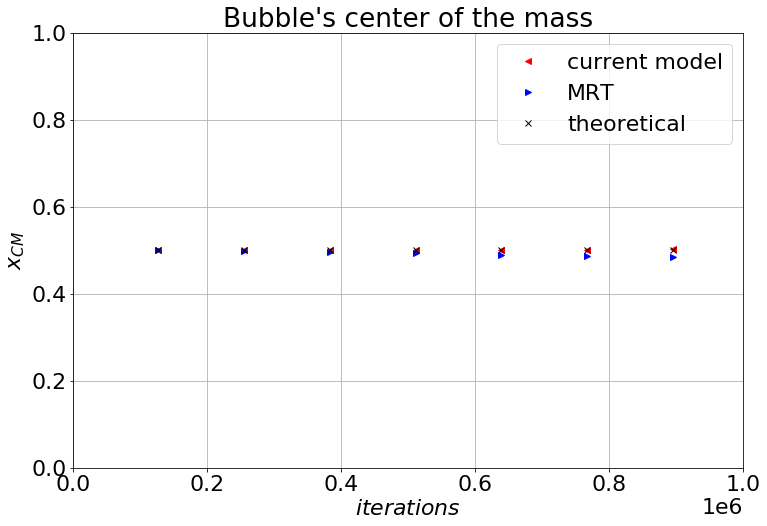

In [3]:

theoretical = np.arange(len(n), dtype='float')
theoretical.fill(0.5)
# make plot
plt.rcParams.update({'font.size': 22})
plt.figure(figsize=(12, 8))
plt.plot(n*1E3, pf_cm_CMx/256, color="red", marker="<", linestyle="", label=r'current model')
plt.plot(n*1E3, pf_mrt_CMx/256, color="blue", marker=">", linestyle="", label=r'MRT')
plt.plot(n*1E3, theoretical, color="black", marker="x", linestyle="", label=r'theoretical')

axes = plt.gca()
axes.set_xlim([0, 1E6])
axes.set_ylim([0, 1.0])

# plt.plot(frames_cm[0]['arc_length'], frames_cm[0]['PhaseField'], color="green", marker="x", linestyle="",  label='test')
plt.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
plt.ylabel(r'$x_{CM}$')
plt.xlabel(r'$iterations$')

plt.title('Bubble\'s center of the mass')
plt.grid(True)
plt.legend()

fig = plt.gcf()  # get current figure
fig.savefig('CMx.png')

plt.show()
# plt.close(fig)    # close the figure